# Neural Network Example

Xây dựng neural network với hai tầng ẩn (hidden layer). Các trọng số và mối liên hệ giữa các tầng ẩn được thiết lập và cài đặt bằng việc sử dụng API của thư viện PyTorch

## Neural Network Overview

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>

## MNIST Dataset Overview



In [ ]:
from __future__ import absolute_import, division, print_function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.autograd import Variable
import numpy as np

In [ ]:
# Chuẩn bị dữ liệu
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Chuyển đổi sang định dạng float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Chuẩn hóa ảnh từ from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.
x_train, x_test, y_train, y_test = torch.from_numpy(x_train), torch.from_numpy(x_test), torch.from_numpy(y_train).type(torch.LongTensor), torch.from_numpy(y_test).type(torch.LongTensor)

In [ ]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
# n_hidden_2 = 256 # 2nd layer number of neurons.

In [ ]:
batch_size = 16

In [ ]:
trainloader = []
for (i,j) in zip(x_train, y_train):
    trainloader.append([i,j])
trainloader = torch.utils.data.DataLoader(trainloader, shuffle=True, batch_size=batch_size)

testloader = []
for (i,j) in zip(x_test, y_test):
    testloader.append([i,j])
testloader = torch.utils.data.DataLoader(testloader, shuffle=True, batch_size=batch_size)

## Hiển thị một vài ví dụ

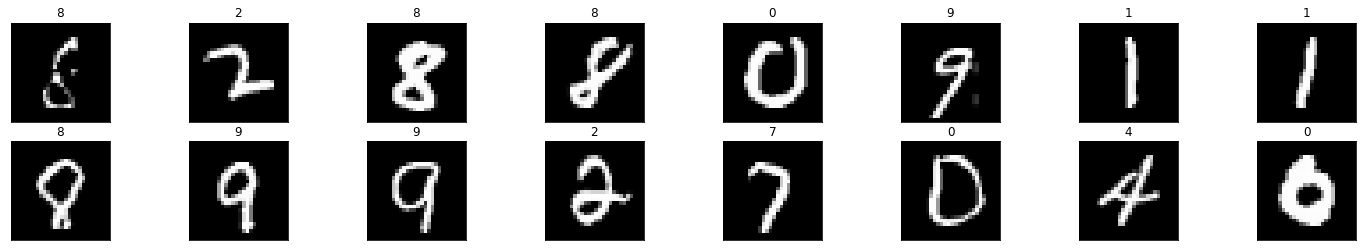

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
    
dataiter = iter(trainloader)
images, labels = dataiter.next()
images = images.numpy()

# hiển thị dữ liệu theo từng batch và nhãn tương ứng
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, batch_size/2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(str(labels[idx].item()))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

## định nghĩa mạng
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(num_features, n_hidden_1)
        # linear layer (n_hidden -> 10 classes)
        self.fc2 = nn.Linear(n_hidden_1, num_classes)

    def forward(self, x):
        # chuyển từ định dạng ma trận thành vector
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

# initialize the NN
model = MLPModel()
print(model)

In [ ]:
import torch.optim as optim
# trong hàm loss cross entropy đã áp dụng hàm soft max cho vector đầu ra
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
def accuracy():
    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            # calculate outputs by running images through the network
            outputs = model(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct/total

In [ ]:
losses = []
for epoch in range(100):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    losses.append(running_loss)
    if epoch % 10 == 9:
        print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

print('Finished Training')

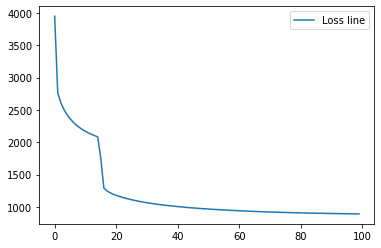

In [ ]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.plot([i for i in range(len(losses))], losses, label='Loss line')
# plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

## Bài tập

*   Tiến hành huấn luyện mô hình với số lượng epoch lần lượt là 50, 100, 150.Rút ra nhận xét.





*   Hiển thị một số kết quả



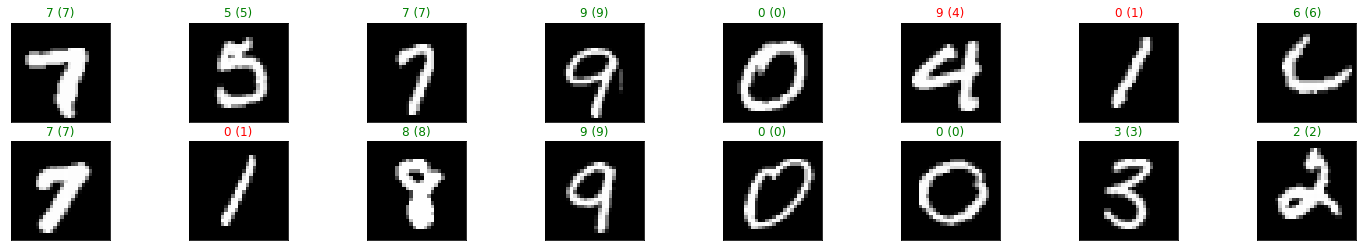

In [ ]:
# obtain one batch of test images
dataiter = iter(testloader)
images, labels = dataiter.next()

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# prep images for display
images = images.numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, batch_size/2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

In [ ]:
# Huấn luyện mô hình với số epoch lần lượt là 50, 100, 150
results_epochs = {}

for n_epochs in [50, 100, 150]:
    model_exp = MLPModel()
    optimizer_exp = optim.SGD(model_exp.parameters(), lr=0.01)
    losses_exp = []

    for epoch in range(n_epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            optimizer_exp.zero_grad()
            outputs = model_exp(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_exp.step()
            running_loss += loss.item()
        losses_exp.append(running_loss)

    # Đánh giá trên tập test
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model_exp(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    results_epochs[n_epochs] = (acc, losses_exp)
    print(f'Epochs: {n_epochs:3d} | Test accuracy: {acc:.4f}')

# Vẽ đường loss cho từng cấu hình
plt.figure(figsize=(10, 4))
for n_epochs, (acc, losses_exp) in results_epochs.items():
    plt.plot(losses_exp, label=f'{n_epochs} epochs (acc={acc:.3f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss theo số epoch huấn luyện')
plt.legend()
plt.show()

# Nhận xét
print("\nNhận xét:")
print("- Khi tăng số epoch từ 50 lên 100, accuracy tăng rõ rệt vì mô hình có thêm thời gian học.")
print("- Từ 100 lên 150 epoch, accuracy tăng ít hơn, cho thấy mô hình gần hội tụ.")
print("- Nếu tiếp tục tăng epoch quá nhiều, mô hình có thể bị overfitting trên tập train.")

## Bài tập

*   Thiết lập thêm 3 mạng nơ ron với số tầng ẩn lần lượt là 3,5 (số lượng nơ ron của các tầng tùy ý). Với mỗi mạng mới được sinh ra, áp dụng learning-rate lần lượt bằng 0.1, 0,05, 0.001 để huấn luyện. Huấn luyện qua khoảng 100 epoch.
*   Chia tập train hiện có thành 2 phần. **85%** dữ liệu làm tập **train**, **15%** còn lại làm tập **dev**. Huấn luyện các mô hình tạo ra ở bước trên với tập **train** mới, sau đó kiểm thử trên tập **dev**. 
* Dùng các model kiểm thử trên tập **test**. So sánh model cho kết quả tốt nhất khi kiểm thử trên 2 tập này và rút ra nhận xét về vai trò của tập **dev**



In [ ]:
# Chia tập train thành 85% train / 15% dev
from torch.utils.data import random_split, DataLoader as DL

full_train = []
for (i, j) in zip(x_train, y_train):
    full_train.append([i, j])

train_size = int(0.85 * len(full_train))
dev_size = len(full_train) - train_size
train_subset, dev_subset = random_split(full_train, [train_size, dev_size])

trainloader_new = DL(train_subset, shuffle=True, batch_size=batch_size)
devloader = DL(dev_subset, shuffle=False, batch_size=batch_size)

# Định nghĩa 3 mạng với số tầng ẩn khác nhau
class MLP3Hidden(nn.Module):
    def __init__(self):
        super(MLP3Hidden, self).__init__()
        self.fc1 = nn.Linear(num_features, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.out(x)

class MLP5Hidden(nn.Module):
    def __init__(self):
        super(MLP5Hidden, self).__init__()
        self.fc1 = nn.Linear(num_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        return self.out(x)

def evaluate_model(model, loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

def train_and_eval(model, lr, n_epochs=100):
    opt = optim.SGD(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        for data in trainloader_new:
            inputs, labels = data
            opt.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            opt.step()
    dev_acc = evaluate_model(model, devloader)
    test_acc = evaluate_model(model, testloader)
    return dev_acc, test_acc

# 3 mạng với learning-rate lần lượt là 0.1, 0.05, 0.001
configs = [
    ('MLP 3 hidden layers, lr=0.1',   MLP3Hidden(),  0.1),
    ('MLP 3 hidden layers, lr=0.05',  MLP3Hidden(),  0.05),
    ('MLP 5 hidden layers, lr=0.001', MLP5Hidden(),  0.001),
]

print(f"{'Model':<40} {'Dev Acc':>10} {'Test Acc':>10}")
print('-' * 62)
best_dev = -1
best_name = ''
for name, mdl, lr in configs:
    dev_acc, test_acc = train_and_eval(mdl, lr)
    print(f'{name:<40} {dev_acc:>10.4f} {test_acc:>10.4f}')
    if dev_acc > best_dev:
        best_dev = dev_acc
        best_name = name

print(f'\nModel tốt nhất trên tập dev: {best_name} (dev acc = {best_dev:.4f})')

print("\nNhận xét:")
print("- Tập dev giúp chọn model tốt nhất mà không 'nhìn' vào tập test.")
print("- Nếu dùng test acc để chọn model, ta vô tình rò rỉ thông tin test,")
print("  dẫn đến đánh giá quá lạc quan so với dữ liệu thực tế.")
print("- Vai trò tập dev: là tập trung gian để điều chỉnh hyperparameter và chọn kiến trúc.")